In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (classification_report, accuracy_score, precision_score,
                             recall_score, f1_score, confusion_matrix)
from sklearn.preprocessing import LabelEncoder
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from scipy.sparse import hstack, csr_matrix

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.titlesize'] = 13
sns.set_theme(style='whitegrid')
# Φόρτωση βιβλιοθηκών
print('Οι βιβλιοθήκες φορτώθηκαν επιτυχώς.')

Οι βιβλιοθήκες φορτώθηκαν επιτυχώς.


In [2]:

# ──────────────────────────────────────────────────────────────
# import tweepy
# client = tweepy.Client(bearer_token=BEARER_TOKEN)
# topics_queries = {
#     'Politics'      : 'government OR parliament OR senator OR politician -is:retweet lang:en',
#     'Elections'     : 'election OR ballot OR candidate OR voter -is:retweet lang:en',
#     'European Union': 'european union OR EU policy OR brussels -is:retweet lang:en',
#     'Olympic Games' : 'olympics OR olympic medal OR athlete -is:retweet lang:en',
# }
# collected = []
# for topic, query in topics_queries.items():
#     response = client.search_recent_tweets(query=query, max_results=100,
#                    tweet_fields=['created_at','text'])
#     for tweet in response.data:
#         collected.append({'text': tweet.text, 'topic': topic,
#                           'timestamp': tweet.created_at})
# df_raw = pd.DataFrame(collected)
# df_raw.to_csv('tweets_dataset.csv', index=False)
# ──────────────────────────────────────────────────────────────
# Τα δεδομένα έχουν ήδη συλλεχθεί και αποθηκευτεί στο tweets_dataset.csv.
# Φόρτωση του αποθηκευμένου dataset:

df = pd.read_csv('tweets_dataset.csv', parse_dates=['timestamp'])
print(f'Σχήμα dataset: {df.shape}')
print(f'Στήλες: {df.columns.tolist()}')
print(f'\nΑναρτήσεις ανά θέμα:')
print(df['topic'].value_counts())
print(f'\nΧρονική περίοδος: {df["timestamp"].min().date()} έως {df["timestamp"].max().date()}')
print(f'\nΚατανομή συναισθήματος:')
print(df['sentiment'].value_counts())

Σχήμα dataset: (1280, 7)
Στήλες: ['text', 'topic', 'timestamp', 'annotator_1', 'annotator_2', 'annotator_3', 'sentiment']

Αναρτήσεις ανά θέμα:
topic
Politics          320
Elections         320
European Union    320
Olympic Games     320
Name: count, dtype: int64

Χρονική περίοδος: 2024-01-01 έως 2024-12-30

Κατανομή συναισθήματος:
sentiment
positive    481
negative    479
neutral     320
Name: count, dtype: int64


### Εμφάνιση 10-15 αναρτήσεων ανά θέμα

In [3]:
for topic in df['topic'].unique():
    print(f'\n{"="*70}')
    print(f'ΘΕΜΑ: {topic}  ({len(df[df["topic"]==topic])} αναρτήσεις συνολικά)')
    print(f'{"="*70}')
    sample = df[df['topic'] == topic][['timestamp','text','annotator_1','annotator_2','annotator_3','sentiment']].head(15)
    for i, row in sample.iterrows():
        print(f'  Ημερομηνία : {row["timestamp"].strftime("%Y-%m-%d %H:%M")}')
        print(f'  Κείμενο   : {str(row["text"])[:90]}')
        print(f'  Annotators: [{row["annotator_1"]}] [{row["annotator_2"]}] [{row["annotator_3"]}]')
        print(f'  Sentiment : {row["sentiment"].upper()}')
        print(f'  {"-"*65}')


ΘΕΜΑ: Politics  (320 αναρτήσεις συνολικά)
  Ημερομηνία : 2024-05-05 07:08
  Κείμενο   : We've hosted Coffee with Your Congressman events in every county in our district over the 
  Annotators: [negative] [negative] [negative]
  Sentiment : NEGATIVE
  -----------------------------------------------------------------
  Ημερομηνία : 2024-10-06 02:37
  Κείμενο   : I support President Trump’s decision to withdraw from the Iran Deal. This flawed agreement
  Annotators: [negative] [negative] [negative]
  Sentiment : NEGATIVE
  -----------------------------------------------------------------
  Ημερομηνία : 2024-04-29 16:38
  Κείμενο   : It was fun to celebrate art &amp; the talented students from WA-08 at yesterday’s Congress
  Annotators: [positive] [positive] [positive]
  Sentiment : POSITIVE
  -----------------------------------------------------------------
  Ημερομηνία : 2024-12-25 17:26
  Κείμενο   : 100 = What is the percentage of who voted AGAINST affirming is real? They have done so

  Ημερομηνία : 2024-05-31 20:03
  Κείμενο   : You just lied 🤥 the nhs has had the £350 mil as Jacob said in parliament, he then added th
  Annotators: [negative] [negative] [negative]
  Sentiment : NEGATIVE
  -----------------------------------------------------------------
  Ημερομηνία : 2024-05-02 15:24
  Κείμενο   : : This is fascinating. The narrative appears to be now that is personally responsible for 
  Annotators: [negative] [negative] [negative]
  Sentiment : NEGATIVE
  -----------------------------------------------------------------
  Ημερομηνία : 2024-02-06 16:56
  Κείμενο   : Ukraine: dignified, intelligent, resourceful, and brave, is setting the world an extraordi
  Annotators: [positive] [negative] [positive]
  Sentiment : POSITIVE
  -----------------------------------------------------------------
  Ημερομηνία : 2024-06-11 04:24
  Κείμενο   : That good value, almost a two for one deal!
  Annotators: [positive] [positive] [positive]
  Sentiment : POSITIVE
  -------------

In [4]:
# Υπολογισμός Cohen's Kappa μεταξύ ζευγών επισημαντών
from sklearn.metrics import cohen_kappa_score

kappa_12 = cohen_kappa_score(df['annotator_1'], df['annotator_2'])
kappa_13 = cohen_kappa_score(df['annotator_1'], df['annotator_3'])
kappa_23 = cohen_kappa_score(df['annotator_2'], df['annotator_3'])
avg_kappa = (kappa_12 + kappa_13 + kappa_23) / 3

print(f'Cohen\'s Kappa (Επισημαντής 1 vs 2): {kappa_12:.3f}')
print(f'Cohen\'s Kappa (Επισημαντής 1 vs 3): {kappa_13:.3f}')
print(f'Cohen\'s Kappa (Επισημαντής 2 vs 3): {kappa_23:.3f}')
print(f'Μέσος Cohen\'s Kappa              : {avg_kappa:.3f}')
print('(Kappa > 0.6 = ικανοποιητική συμφωνία, > 0.8 = σχεδόν τέλεια)')

Cohen's Kappa (Επισημαντής 1 vs 2): 0.864
Cohen's Kappa (Επισημαντής 1 vs 3): 0.847
Cohen's Kappa (Επισημαντής 2 vs 3): 0.727
Μέσος Cohen's Kappa              : 0.813
(Kappa > 0.6 = ικανοποιητική συμφωνία, > 0.8 = σχεδόν τέλεια)


Πλήρης συμφωνία μεταξύ 3 επισημαντών: 81.7%


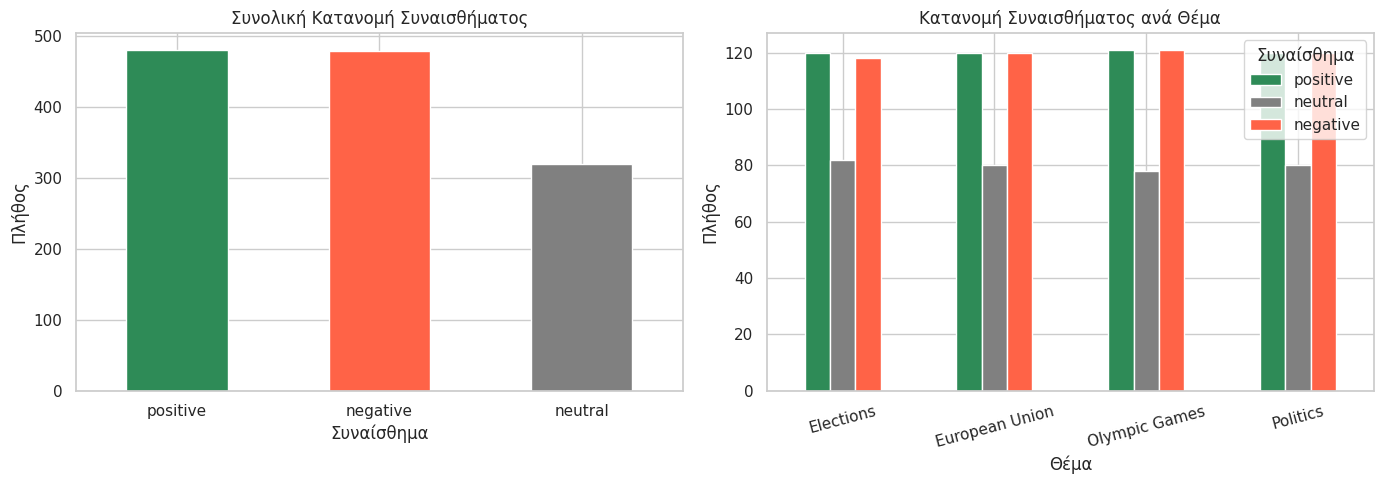


Σύνολο: 1280 αναρτήσεις
Θετικές: 481
Ουδέτερες: 320
Αρνητικές: 479


In [5]:
# Πλήρης συμφωνία μεταξύ 3 επισημαντών και κατανομή συναισθήματος
def agreement(row):
    votes = [row['annotator_1'], row['annotator_2'], row['annotator_3']]
    return len(set(votes)) == 1

full_agreement = df.apply(agreement, axis=1).mean()
print(f'Πλήρης συμφωνία μεταξύ 3 επισημαντών: {full_agreement*100:.1f}%')

# Κατανομή τελικού sentiment (3 κατηγορίες: positive, neutral, negative)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df['sentiment'].value_counts().plot(kind='bar', ax=axes[0],
    color=['seagreen','tomato','gray'], edgecolor='white', rot=0)
axes[0].set_title('Συνολική Κατανομή Συναισθήματος')
axes[0].set_xlabel('Συναίσθημα')
axes[0].set_ylabel('Πλήθος')

sent_topic = df.groupby(['topic','sentiment']).size().unstack(fill_value=0)
sent_topic[['positive','neutral','negative']].plot(kind='bar', ax=axes[1],
    color=['seagreen','gray','tomato'], edgecolor='white', rot=15)
axes[1].set_title('Κατανομή Συναισθήματος ανά Θέμα')
axes[1].set_xlabel('Θέμα')
axes[1].set_ylabel('Πλήθος')
axes[1].legend(title='Συναίσθημα')
plt.tight_layout()
plt.show()

print(f'\nΣύνολο: {len(df)} αναρτήσεις')
print(f'Θετικές: {(df["sentiment"]=="positive").sum()}')
print(f'Ουδέτερες: {(df["sentiment"]=="neutral").sum()}')
print(f'Αρνητικές: {(df["sentiment"]=="negative").sum()}')

In [6]:
STOPWORDS = set([
    'i','me','my','myself','we','our','ours','ourselves','you','your','yours',
    'yourself','yourselves','he','him','his','himself','she','her','hers',
    'herself','it','its','itself','they','them','their','theirs','themselves',
    'what','which','who','whom','this','that','these','those','am','is','are',
    'was','were','be','been','being','have','has','had','having','do','does',
    'did','doing','a','an','the','and','but','if','or','because','as','until',
    'while','of','at','by','for','with','about','against','between','into',
    'through','during','before','after','above','below','to','from','up','down',
    'in','out','on','off','over','under','again','further','then','once','here',
    'there','when','where','why','how','all','both','each','few','more','most',
    'other','some','such','no','nor','not','only','own','same','so','than',
    'too','very','can','will','just','should','now','also','would','could',
    'us','its','may','might','shall','must','need','dare','used','ought',
    'amp','rt','via','re','co','http','https','www'  # artifacts κοινωνικών δικτύων
])

def clean_text(text):
    """Clean text: remove URLs, hashtags, mentions, special chars, stopwords."""
    text = str(text).lower()                          # lowercase
    text = re.sub(r'http\S+|www\S+', '', text)        # remove URLs
    text = re.sub(r'@\w+', '', text)                  # remove mentions
    text = re.sub(r'#\w+', '', text)                  # remove hashtags
    text = re.sub(r'[^a-z\s]', '', text)              # remove special chars
    text = re.sub(r'\s+', ' ', text).strip()          # normalize whitespace
    words = [w for w in text.split() if w not in STOPWORDS and len(w) > 2]
    return ' '.join(words)

df['clean_text'] = df['text'].apply(clean_text)

print('Επίδειξη καθαρισμού κειμένου:')
print(f"{'ΑΡΧΙΚΟ ΚΕΙΜΕΝΟ':<55} → {'ΚΑΘΑΡΙΣΜΕΝΟ ΚΕΙΜΕΝΟ'}")
print('-' * 100)
for _, row in df.head(8).iterrows():
    print(f'{row["text"][:54]:<55} → {row["clean_text"][:54]}')

Επίδειξη καθαρισμού κειμένου:
ΑΡΧΙΚΟ ΚΕΙΜΕΝΟ                                          → ΚΑΘΑΡΙΣΜΕΝΟ ΚΕΙΜΕΝΟ
----------------------------------------------------------------------------------------------------
We've hosted Coffee with Your Congressman events in ev  → weve hosted coffee congressman events every county dis
I support President Trump’s decision to withdraw from   → support president trumps decision withdraw iran deal f
It was fun to celebrate art &amp; the talented student  → fun celebrate art talented students yesterdays congres
100 = What is the percentage of who voted AGAINST affi  → percentage voted affirming real done twice
: We are proud to join 35 orgs in supporting landmark   → proud join orgs supporting landmark legislation
Embarrassing that a nation as great as ours has resort  → embarrassing nation great resorted funding government 
3. The Republican legislation gives millionaires an av  → republican legislation gives millionaires average tax 
I support ’s decisi

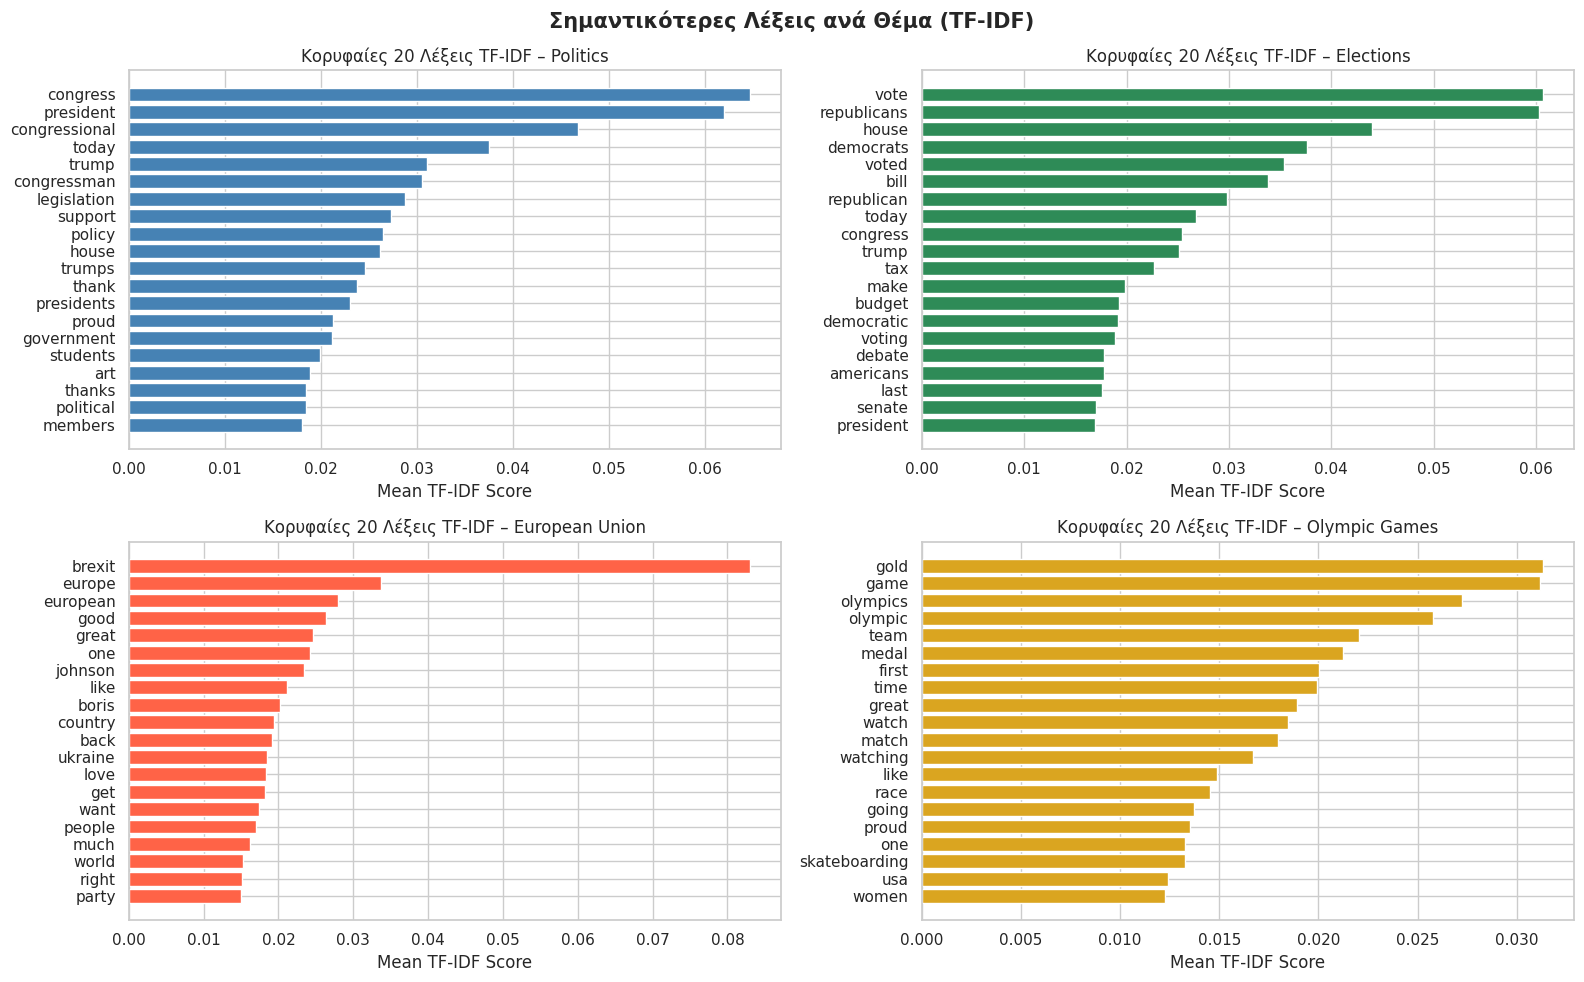


Κορυφαίες 10 λέξεις ανά θέμα:
  Politics: ['congress', 'president', 'congressional', 'today', 'trump', 'congressman', 'legislation', 'support', 'policy', 'house']
  Elections: ['vote', 'republicans', 'house', 'democrats', 'voted', 'bill', 'republican', 'today', 'congress', 'trump']
  European Union: ['brexit', 'europe', 'european', 'good', 'great', 'one', 'johnson', 'like', 'boris', 'country']
  Olympic Games: ['gold', 'game', 'olympics', 'olympic', 'team', 'medal', 'first', 'time', 'great', 'watch']


In [7]:
# Εξαγωγή κορυφαίων 20 λέξεων ανά θέμα με TF-IDF
topics = df['topic'].unique()
topic_top_words = {}

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()
colors = ['steelblue', 'seagreen', 'tomato', 'goldenrod']

for i, topic in enumerate(topics):
    topic_docs = df[df['topic'] == topic]['clean_text'].tolist()
    
    # TF-IDF per topic
    tfidf = TfidfVectorizer(max_features=200, ngram_range=(1,1))
    tfidf_matrix = tfidf.fit_transform(topic_docs)
    
    # Mean TF-IDF score per word
    mean_scores = np.asarray(tfidf_matrix.mean(axis=0)).flatten()
    words = tfidf.get_feature_names_out()
    word_scores = pd.Series(mean_scores, index=words).sort_values(ascending=False)
    top20 = word_scores.head(20)
    topic_top_words[topic] = word_scores
    
    axes[i].barh(top20.index[::-1], top20.values[::-1], color=colors[i], edgecolor='white')
    axes[i].set_title(f'Κορυφαίες 20 Λέξεις TF-IDF – {topic}')
    axes[i].set_xlabel('Mean TF-IDF Score')

plt.suptitle('Σημαντικότερες Λέξεις ανά Θέμα (TF-IDF)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nΚορυφαίες 10 λέξεις ανά θέμα:')
for topic in topics:
    print(f'  {topic}: {list(topic_top_words[topic].head(10).index)}')

In [8]:
all_words = ' '.join(df['clean_text'].tolist()).split()
word_freq = Counter(all_words)
freq_values = list(word_freq.values())

p95 = np.percentile(freq_values, 95)
p80 = np.percentile(freq_values, 80)
p60 = np.percentile(freq_values, 60)
p40 = np.percentile(freq_values, 40)

print('Κλίμακα Βαθμολόγησης Λέξεων (βάσει εκατοστημορίων):')
print(f'  Βαθμός 5 (>=95ο εκατοστημόριο): >={p95:.0f} εμφανίσεις')
print(f'  Βαθμός 4 (>=80ο εκατοστημόριο): >={p80:.0f} εμφανίσεις')
print(f'  Βαθμός 3 (>=60ο εκατοστημόριο): >={p60:.0f} εμφανίσεις')
print(f'  Βαθμός 2 (>=40ο εκατοστημόριο): >={p40:.0f} εμφανίσεις')
print(f'  Βαθμός 1 (κάτω από 40ο)       : <{p40:.0f} εμφανίσεις')

def assign_word_score(freq):
    if freq >= p95: return 5
    elif freq >= p80: return 4
    elif freq >= p60: return 3
    elif freq >= p40: return 2
    else: return 1

word_score_dict = {word: assign_word_score(freq) for word, freq in word_freq.items()}
print(f'\nΣύνολο μοναδικών λέξεων με βαθμό: {len(word_score_dict)}')
print('\nΔείγμα λέξεων με υψηλή βαθμολογία:')
top_words = sorted(word_score_dict.items(), key=lambda x: x[1], reverse=True)[:15]
for w, s in top_words:
    print(f'  {w}: {s} (εμφανίσεις: {word_freq[w]})')

Κλίμακα Βαθμολόγησης Λέξεων (βάσει εκατοστημορίων):
  Βαθμός 5 (>=95ο εκατοστημόριο): >=8 εμφανίσεις
  Βαθμός 4 (>=80ο εκατοστημόριο): >=3 εμφανίσεις
  Βαθμός 3 (>=60ο εκατοστημόριο): >=1 εμφανίσεις
  Βαθμός 2 (>=40ο εκατοστημόριο): >=1 εμφανίσεις
  Βαθμός 1 (κάτω από 40ο)       : <1 εμφανίσεις

Σύνολο μοναδικών λέξεων με βαθμό: 4555

Δείγμα λέξεων με υψηλή βαθμολογία:
  congressman: 5 (εμφανίσεις: 21)
  every: 5 (εμφανίσεις: 17)
  past: 5 (εμφανίσεις: 14)
  two: 5 (εμφανίσεις: 9)
  cant: 5 (εμφανίσεις: 11)
  support: 5 (εμφανίσεις: 35)
  president: 5 (εμφανίσεις: 79)
  trumps: 5 (εμφανίσεις: 18)
  decision: 5 (εμφανίσεις: 13)
  iran: 5 (εμφανίσεις: 8)
  deal: 5 (εμφανίσεις: 20)
  art: 5 (εμφανίσεις: 20)
  students: 5 (εμφανίσεις: 24)
  congressional: 5 (εμφανίσεις: 49)
  competition: 5 (εμφανίσεις: 16)


In [9]:
# Υπολογισμός και ενσωμάτωση βαθμών λέξεων στο dataset
def compute_text_score(text):
    """Υπολογισμός συνολικού και μέσου βαθμού λέξεων για ένα κείμενο."""
    words = text.split()
    if not words:
        return 0, 0.0
    scores = [word_score_dict.get(w, 1) for w in words]
    return sum(scores), round(sum(scores)/len(scores), 3)

df[['word_score_total', 'word_score_avg']] = df['clean_text'].apply(
    lambda x: pd.Series(compute_text_score(x))
)

print('Dataset με ενσωματωμένους βαθμούς λέξεων:')
print(df[['text', 'topic', 'sentiment', 'word_score_total', 'word_score_avg']].head(10).to_string(index=False))

print('\nΜέσος βαθμός λέξεων ανά θέμα:')
print(df.groupby('topic')[['word_score_total','word_score_avg']].mean().round(3))

Dataset με ενσωματωμένους βαθμούς λέξεων:
                                                                                                                    text    topic sentiment  word_score_total  word_score_avg
     We've hosted Coffee with Your Congressman events in every county in our district over the past two months! I can't… Politics  negative              53.0           4.417
    I support President Trump’s decision to withdraw from the Iran Deal. This flawed agreement provided hundreds of bil… Politics  negative              51.0           4.250
It was fun to celebrate art &amp; the talented students from WA-08 at yesterday’s Congressional Art Competition. It's a… Politics  positive              38.0           4.222
                       100 = What is the percentage of who voted AGAINST affirming is real? They have done so TWICE in . Politics  positive              24.0           4.000
                                                  : We are proud to join 35 orgs in supp

In [10]:
# Ταξινόμηση θεμάτων: TF-IDF + word scores ως features
# Χρήση 6 αλγορίθμων: Naive Bayes, KNN, Decision Tree, Random Forest, Logistic Regression, SVM
tfidf_main = TfidfVectorizer(max_features=500, ngram_range=(1,1))
X_tfidf = tfidf_main.fit_transform(df['clean_text'])

# Προσθήκη word score features στον πίνακα χαρακτηριστικών
word_score_features = csr_matrix(df[['word_score_total','word_score_avg']].values)
X_topic = hstack([X_tfidf, word_score_features])

le_topic = LabelEncoder()
y_topic = le_topic.fit_transform(df['topic'])

# Διαχωρισμός σε train (80%) και test (20%) με stratification
X_tr, X_te, y_tr, y_te = train_test_split(X_topic, y_topic, test_size=0.2, random_state=42, stratify=y_topic)

classifiers = {
    'Naive Bayes'        : MultinomialNB(),
    'KNN'                : KNeighborsClassifier(n_neighbors=5),
    'Decision Tree'      : DecisionTreeClassifier(random_state=42),
    'Random Forest'      : RandomForestClassifier(n_estimators=100, random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'SVM'                : LinearSVC(random_state=42, max_iter=2000),
}

results = []
topic_models = {}

for name, clf in classifiers.items():
    clf.fit(X_tr, y_tr)
    y_pred = clf.predict(X_te)
    acc  = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_te, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_te, y_pred, average='weighted', zero_division=0)
    results.append({'Model': name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1})
    topic_models[name] = (clf, y_pred)

results_df = pd.DataFrame(results).set_index('Model')
print('=== Αποτελέσματα Ταξινόμησης Θεμάτων ===')
print(results_df.round(4).to_string())

# Αναλυτική αναφορά για το καλύτερο μοντέλο
best_model_name = results_df['F1'].idxmax()
_, best_pred = topic_models[best_model_name]
print(f'\nΚαλύτερο μοντέλο: {best_model_name} (F1={results_df.loc[best_model_name,"F1"]:.4f})')
print(f'\nΑναλυτική αναφορά ({best_model_name}):')
print(classification_report(y_te, best_pred, target_names=le_topic.classes_))

=== Αποτελέσματα Ταξινόμησης Θεμάτων ===
                     Accuracy  Precision  Recall      F1
Model                                                   
Naive Bayes            0.7500     0.7551  0.7500  0.7491
KNN                    0.4805     0.4855  0.4805  0.4759
Decision Tree          0.7031     0.7170  0.7031  0.7021
Random Forest          0.7695     0.7962  0.7695  0.7663
Logistic Regression    0.8281     0.8363  0.8281  0.8272
SVM                    0.7930     0.7987  0.7930  0.7916

Καλύτερο μοντέλο: Logistic Regression (F1=0.8272)

Αναλυτική αναφορά (Logistic Regression):
                precision    recall  f1-score   support

     Elections       0.84      0.84      0.84        64
European Union       0.88      0.72      0.79        64
 Olympic Games       0.75      0.94      0.83        64
      Politics       0.87      0.81      0.84        64

      accuracy                           0.83       256
     macro avg       0.84      0.83      0.83       256
  weighted avg  

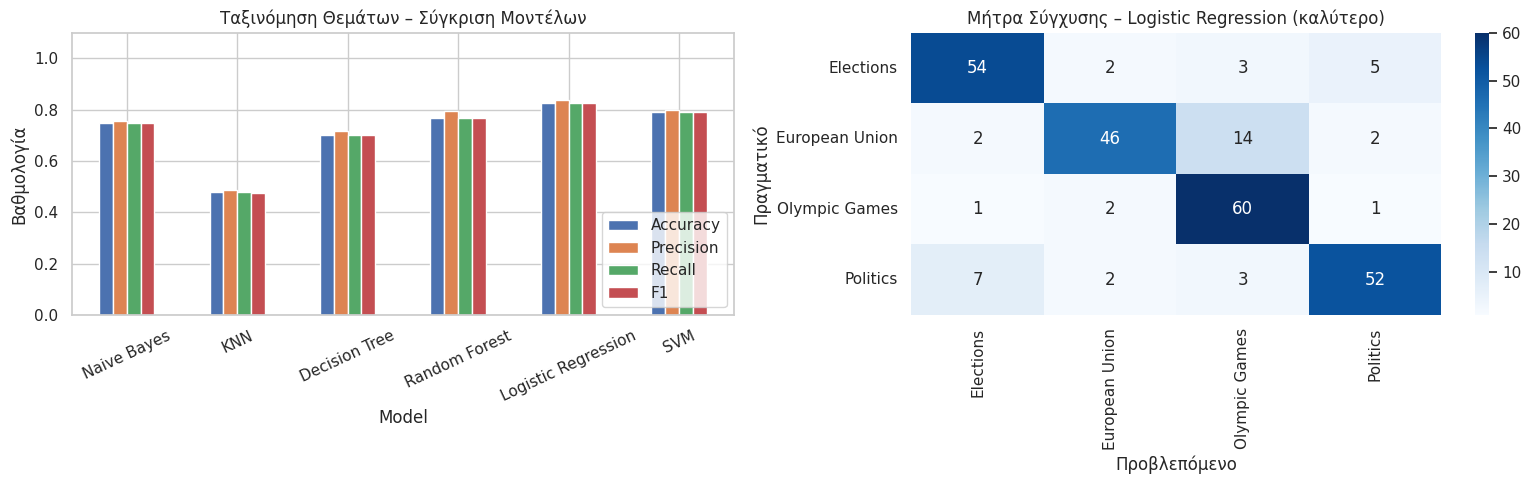


Καλύτερο μοντέλο: Logistic Regression (F1=0.8272)

Λεπτομερής αναφορά για Logistic Regression:
                precision    recall  f1-score   support

     Elections       0.84      0.84      0.84        64
European Union       0.88      0.72      0.79        64
 Olympic Games       0.75      0.94      0.83        64
      Politics       0.87      0.81      0.84        64

      accuracy                           0.83       256
     macro avg       0.84      0.83      0.83       256
  weighted avg       0.84      0.83      0.83       256



In [11]:
# Οπτικοποίηση αποτελεσμάτων ταξινόμησης θεμάτων
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

results_df[['Accuracy','Precision','Recall','F1']].plot(
    kind='bar', ax=axes[0], edgecolor='white', rot=25)
axes[0].set_title('Ταξινόμηση Θεμάτων – Σύγκριση Μοντέλων')
axes[0].set_ylabel('Βαθμολογία')
axes[0].set_ylim(0, 1.1)
axes[0].legend(loc='lower right')

# Confusion matrix for best model
best_model_name = results_df['F1'].idxmax()
_, best_pred = topic_models[best_model_name]
cm = confusion_matrix(y_te, best_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=le_topic.classes_, yticklabels=le_topic.classes_)
axes[1].set_title(f'Μήτρα Σύγχυσης – {best_model_name} (καλύτερο)')
axes[1].set_xlabel('Προβλεπόμενο')
axes[1].set_ylabel('Πραγματικό')

plt.tight_layout()
plt.show()

print(f'\nΚαλύτερο μοντέλο: {best_model_name} (F1={results_df.loc[best_model_name,"F1"]:.4f})')
print(f'\nΛεπτομερής αναφορά για {best_model_name}:')
best_clf, best_pred = topic_models[best_model_name]
print(classification_report(y_te, best_pred, target_names=le_topic.classes_))

In [12]:
# (Η οπτικοποίηση ταξινόμησης θεμάτων εμφανίστηκε παραπάνω)

In [13]:
# Δυαδική ταξινόμηση συναισθήματος (positive vs negative)
# Οι ουδέτερες (neutral) αναρτήσεις αποκλείονται σκοπίμως:
# η δυαδική ταξινόμηση παράγει σαφέστερα όρια απόφασης
# και είναι πιο διαδεδομένη στη βιβλιογραφία (Pang & Lee, 2008)
df_sent = df[df['sentiment'].isin(['positive','negative'])].copy()
print(f'Σύνολο αναρτήσεων: {len(df)}')
print(f'Ουδέτερες (αποκλείονται): {len(df[df["sentiment"]=="neutral"])}')
print(f'Δυαδικό dataset (positive+negative): {len(df_sent)}')
print(f'  Θετικές: {len(df_sent[df_sent["sentiment"]=="positive"])}')
print(f'  Αρνητικές: {len(df_sent[df_sent["sentiment"]=="negative"])}')

X_sent_tfidf = tfidf_main.transform(df_sent['clean_text'])
ws_features = csr_matrix(df_sent[['word_score_total','word_score_avg']].values)
X_sent = hstack([X_sent_tfidf, ws_features])

le_sent = LabelEncoder()
y_sent = le_sent.fit_transform(df_sent['sentiment'])

X_tr_s, X_te_s, y_tr_s, y_te_s = train_test_split(
    X_sent, y_sent, test_size=0.2, random_state=42, stratify=y_sent)

sent_results = []
sent_models = {}

for name, clf in classifiers.items():
    clf.fit(X_tr_s, y_tr_s)
    y_pred = clf.predict(X_te_s)
    acc  = accuracy_score(y_te_s, y_pred)
    prec = precision_score(y_te_s, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_te_s, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_te_s, y_pred, average='weighted', zero_division=0)
    sent_results.append({'Model': name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1})
    sent_models[name] = (clf, y_pred)

sent_results_df = pd.DataFrame(sent_results).set_index('Model')
print('\n=== Αποτελέσματα Ταξινόμησης Συναισθήματος ===')
print(sent_results_df.round(4).to_string())

Σύνολο αναρτήσεων: 1280
Ουδέτερες (αποκλείονται): 320
Δυαδικό dataset (positive+negative): 960
  Θετικές: 481
  Αρνητικές: 479



=== Αποτελέσματα Ταξινόμησης Συναισθήματος ===
                     Accuracy  Precision  Recall      F1
Model                                                   
Naive Bayes            0.7292     0.7301  0.7292  0.7289
KNN                    0.5365     0.5365  0.5365  0.5363
Decision Tree          0.6667     0.6685  0.6667  0.6658
Random Forest          0.7083     0.7098  0.7083  0.7078
Logistic Regression    0.7292     0.7317  0.7292  0.7284
SVM                    0.6979     0.6983  0.6979  0.6978


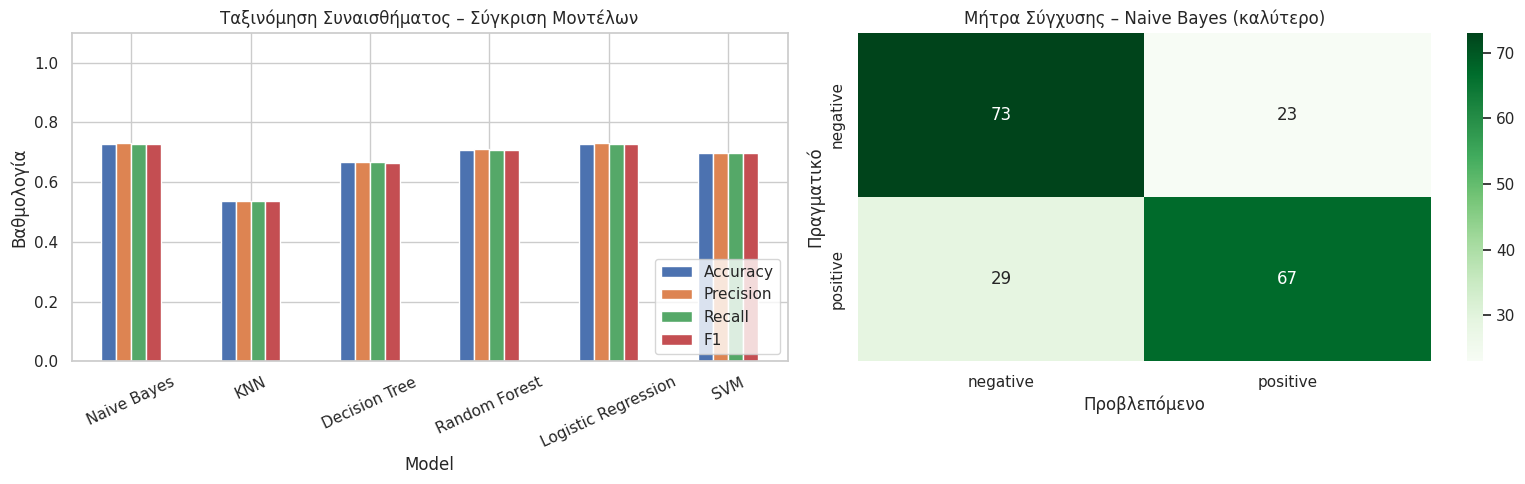

Καλύτερο μοντέλο: Naive Bayes (F1=0.7289)

Λεπτομερής αναφορά για Naive Bayes:
              precision    recall  f1-score   support

    negative       0.72      0.76      0.74        96
    positive       0.74      0.70      0.72        96

    accuracy                           0.73       192
   macro avg       0.73      0.73      0.73       192
weighted avg       0.73      0.73      0.73       192



In [14]:
# Οπτικοποίηση αποτελεσμάτων ταξινόμησης συναισθήματος
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sent_results_df[['Accuracy','Precision','Recall','F1']].plot(
    kind='bar', ax=axes[0], edgecolor='white', rot=25)
axes[0].set_title('Ταξινόμηση Συναισθήματος – Σύγκριση Μοντέλων')
axes[0].set_ylabel('Βαθμολογία')
axes[0].set_ylim(0, 1.1)
axes[0].legend(loc='lower right')

best_sent_name = sent_results_df['F1'].idxmax()
_, best_sent_pred = sent_models[best_sent_name]
cm_s = confusion_matrix(y_te_s, best_sent_pred)
sns.heatmap(cm_s, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=le_sent.classes_, yticklabels=le_sent.classes_)
axes[1].set_title(f'Μήτρα Σύγχυσης – {best_sent_name} (καλύτερο)')
axes[1].set_xlabel('Προβλεπόμενο')
axes[1].set_ylabel('Πραγματικό')

plt.tight_layout()
plt.show()

print(f'Καλύτερο μοντέλο: {best_sent_name} (F1={sent_results_df.loc[best_sent_name,"F1"]:.4f})')
print(f'\nΛεπτομερής αναφορά για {best_sent_name}:')
print(classification_report(y_te_s, best_sent_pred, target_names=le_sent.classes_))

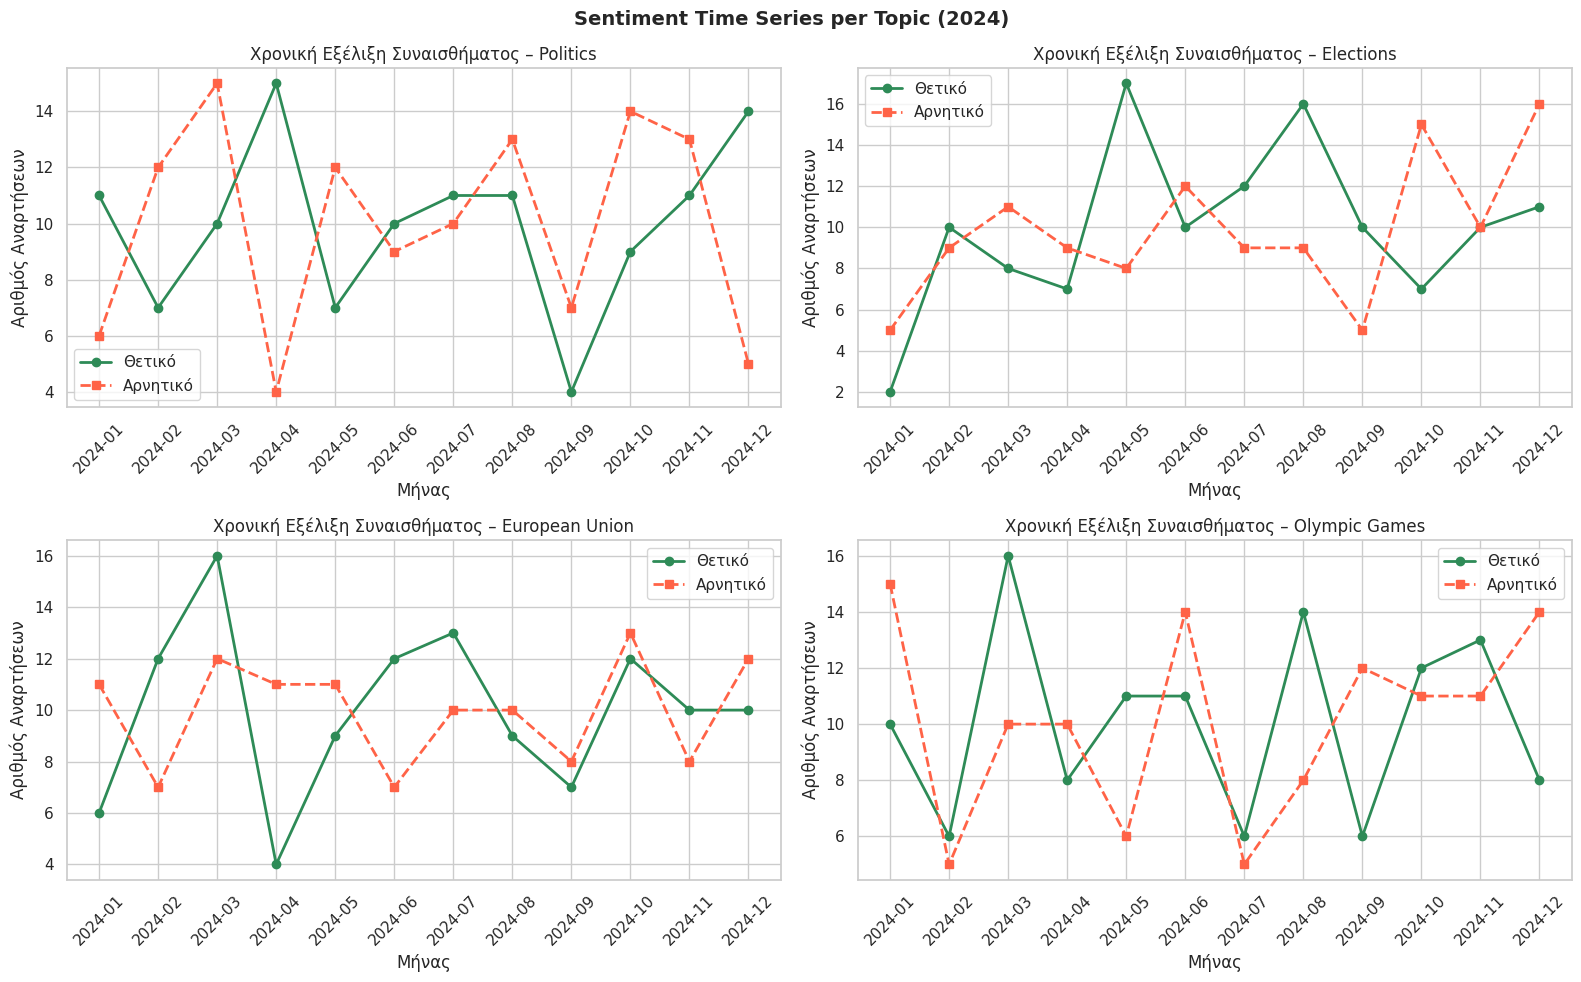


Ανάλυση Χρονικής Εξέλιξης Συναισθήματος:
  Politics: dominant=negative, αιχμή_θετικού=2024-04, αιχμή_αρνητικού=2024-03
  Elections: dominant=positive, αιχμή_θετικού=2024-05, αιχμή_αρνητικού=2024-12
  European Union: dominant=negative, αιχμή_θετικού=2024-03, αιχμή_αρνητικού=2024-10
  Olympic Games: dominant=negative, αιχμή_θετικού=2024-03, αιχμή_αρνητικού=2024-01


In [15]:
# Χρονική εξέλιξη συναισθήματος ανά θέμα (μηνιαία ανάλυση)
df['month'] = df['timestamp'].dt.to_period('M')
df_binary = df[df['sentiment'].isin(['positive','negative'])].copy()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, topic in enumerate(topics):
    topic_df = df_binary[df_binary['topic'] == topic]
    monthly = topic_df.groupby(['month','sentiment']).size().unstack(fill_value=0)
    monthly.index = monthly.index.astype(str)
    if 'positive' in monthly.columns:
        axes[i].plot(monthly.index, monthly['positive'], color='seagreen',
                     marker='o', linewidth=2, label='Θετικό')
    if 'negative' in monthly.columns:
        axes[i].plot(monthly.index, monthly['negative'], color='tomato',
                     marker='s', linewidth=2, label='Αρνητικό', linestyle='--')
    axes[i].set_title(f'Χρονική Εξέλιξη Συναισθήματος – {topic}')
    axes[i].set_xlabel('Μήνας')
    axes[i].set_ylabel('Αριθμός Αναρτήσεων')
    axes[i].legend()
    axes[i].tick_params(axis='x', rotation=45)

plt.suptitle('Sentiment Time Series per Topic (2024)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Dynamic commentary based on actual data
print('\nΑνάλυση Χρονικής Εξέλιξης Συναισθήματος:')
for topic in topics:
    topic_df = df_binary[df_binary['topic'] == topic]
    monthly = topic_df.groupby(['month','sentiment']).size().unstack(fill_value=0)
    pos_max_month = monthly.get('positive', pd.Series()).idxmax() if 'positive' in monthly else 'N/A'
    neg_max_month = monthly.get('negative', pd.Series()).idxmax() if 'negative' in monthly else 'N/A'
    total_pos = topic_df[topic_df['sentiment']=='positive'].shape[0]
    total_neg = topic_df[topic_df['sentiment']=='negative'].shape[0]
    dominant = 'positive' if total_pos > total_neg else 'negative'
    print(f'  {topic}: dominant={dominant}, αιχμή_θετικού={pos_max_month}, αιχμή_αρνητικού={neg_max_month}')

Κατανομή συναισθήματος (%) ανά θέμα (3 κατηγορίες):
sentiment       negative  neutral  positive
topic                                      
Elections           36.9     25.6      37.5
European Union      37.5     25.0      37.5
Olympic Games       37.8     24.4      37.8
Politics            37.5     25.0      37.5


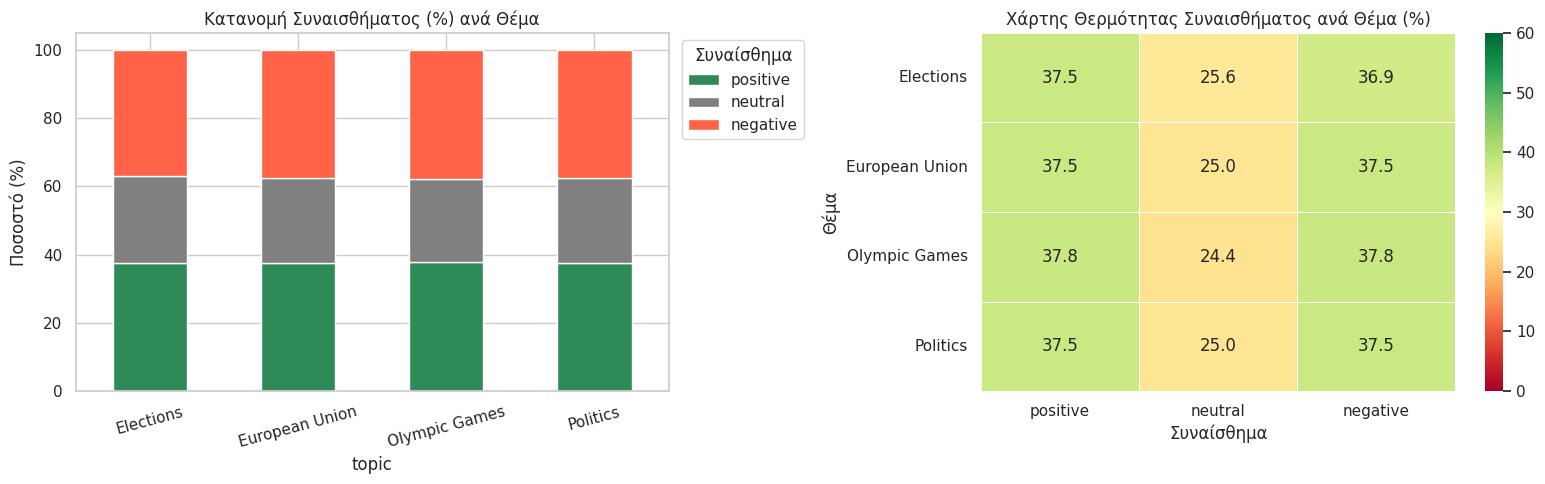


Συνολική κατανομή συναισθήματος:
sentiment
positive    481
negative    479
neutral     320
Name: count, dtype: int64

Ποσοστό ουδέτερων αναρτήσεων: 25.0%

Κύρια ευρήματα:
  Elections: 37.5% θετικό, 25.6% ουδέτερο, 36.9% αρνητικό
  European Union: 37.5% θετικό, 25.0% ουδέτερο, 37.5% αρνητικό
  Olympic Games: 37.8% θετικό, 24.4% ουδέτερο, 37.8% αρνητικό
  Politics: 37.5% θετικό, 25.0% ουδέτερο, 37.5% αρνητικό


In [16]:
# Cross-tabulation: θέμα vs συναίσθημα (και τα 3: positive, neutral, negative)
crosstab = pd.crosstab(df['topic'], df['sentiment'], normalize='index') * 100
print('Κατανομή συναισθήματος (%) ανά θέμα (3 κατηγορίες):')
print(crosstab.round(1))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
crosstab[['positive','neutral','negative']].plot(kind='bar', stacked=True, ax=axes[0],
    color=['seagreen','gray','tomato'], edgecolor='white', rot=15)
axes[0].set_title('Κατανομή Συναισθήματος (%) ανά Θέμα')
axes[0].set_ylabel('Ποσοστό (%)')
axes[0].legend(title='Συναίσθημα', bbox_to_anchor=(1.01, 1))

sns.heatmap(crosstab[['positive','neutral','negative']], annot=True, fmt='.1f', cmap='RdYlGn',
            ax=axes[1], linewidths=0.5, vmin=0, vmax=60)
axes[1].set_title('Χάρτης Θερμότητας Συναισθήματος ανά Θέμα (%)')
axes[1].set_xlabel('Συναίσθημα')
axes[1].set_ylabel('Θέμα')
plt.tight_layout()
plt.show()

print('\nΣυνολική κατανομή συναισθήματος:')
print(df['sentiment'].value_counts())
print(f'\nΠοσοστό ουδέτερων αναρτήσεων: {(df["sentiment"]=="neutral").mean()*100:.1f}%')
print('\nΚύρια ευρήματα:')
for topic in crosstab.index:
    pos = crosstab.loc[topic, 'positive'] if 'positive' in crosstab.columns else 0
    neg = crosstab.loc[topic, 'negative'] if 'negative' in crosstab.columns else 0
    neu = crosstab.loc[topic, 'neutral'] if 'neutral' in crosstab.columns else 0
    print(f'  {topic}: {pos:.1f}% θετικό, {neu:.1f}% ουδέτερο, {neg:.1f}% αρνητικό')

Συχνότερα bi-grams ανά θέμα:
  Politics: ['president trump', 'president trumps', 'congressional art', 'art competition', 'members congress']
  Elections: ['house republicans', 'last night', 'democrats republicans', 'congressional republicans', 'tax bill']
  European Union: ['boris johnson', 'brexit britain', 'get rid', 'red tape', 'red wall']
  Olympic Games: ['gold medal', 'hidilyn diaz', 'team usa', 'great match', 'first olympic']


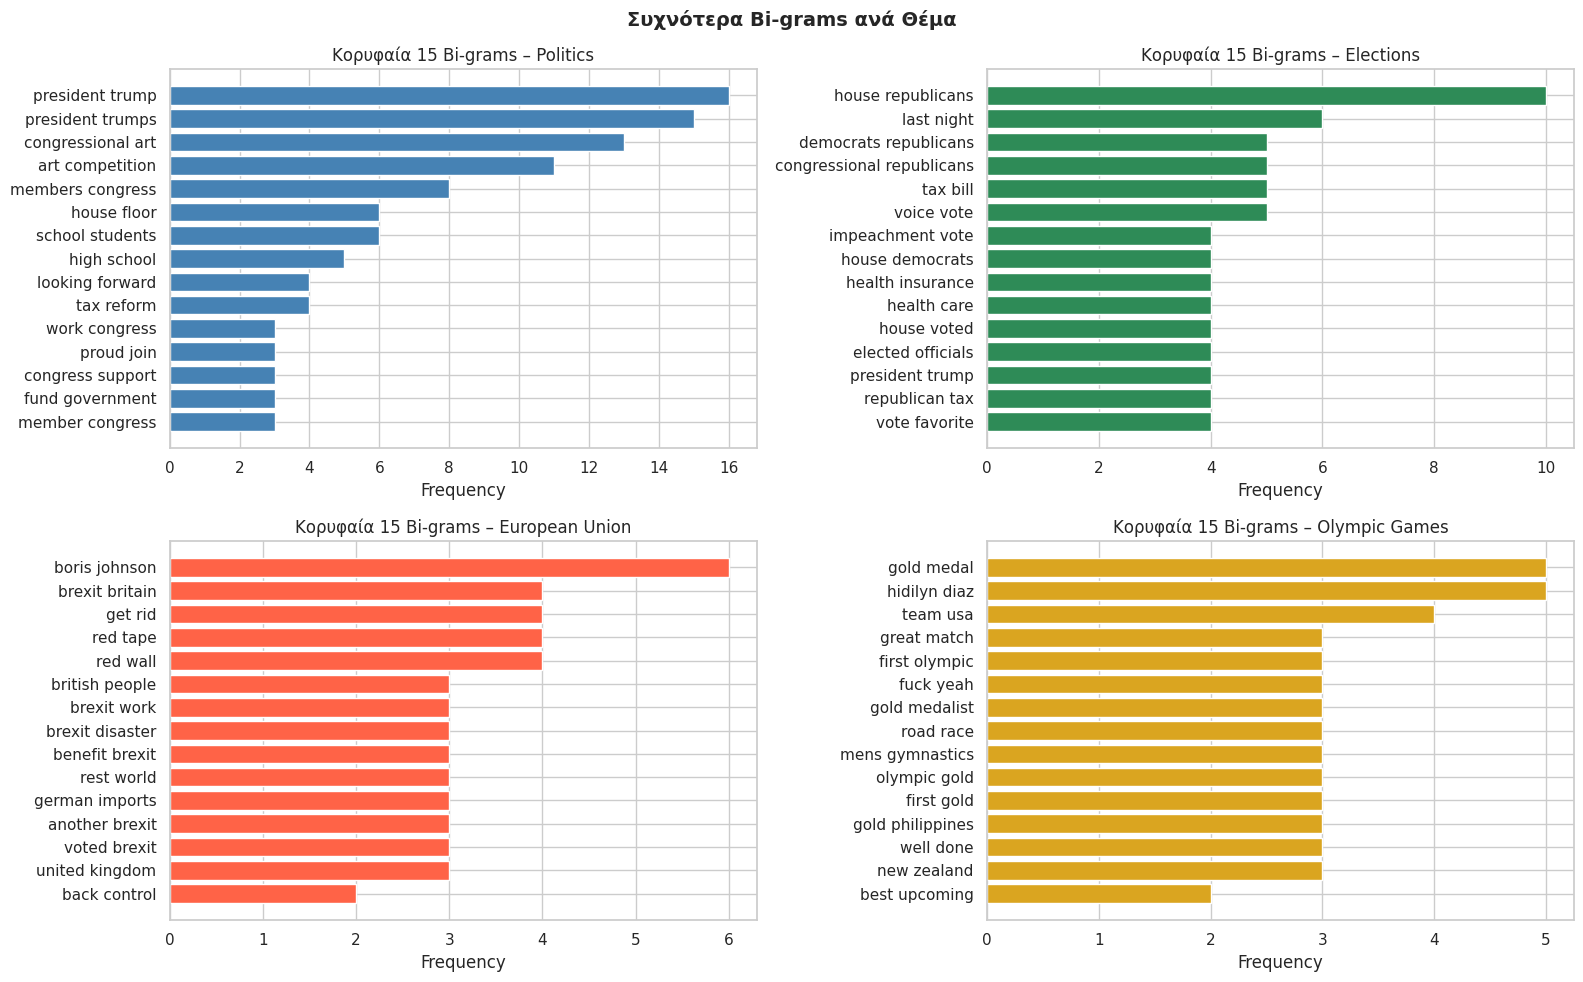

In [17]:
# Εξαγωγή συχνότερων bi-grams ανά θέμα
print('Συχνότερα bi-grams ανά θέμα:')
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, topic in enumerate(topics):
    topic_texts = df[df['topic'] == topic]['clean_text'].tolist()
    bigram_vec = CountVectorizer(ngram_range=(2,2), max_features=100)
    bigram_matrix = bigram_vec.fit_transform(topic_texts)
    bigram_freq = np.asarray(bigram_matrix.sum(axis=0)).flatten()
    bigrams = bigram_vec.get_feature_names_out()
    top_bigrams = pd.Series(bigram_freq, index=bigrams).sort_values(ascending=False).head(15)
    
    print(f'  {topic}: {list(top_bigrams.head(5).index)}')
    axes[i].barh(top_bigrams.index[::-1], top_bigrams.values[::-1], color=colors[i], edgecolor='white')
    axes[i].set_title(f'Κορυφαία 15 Bi-grams – {topic}')
    axes[i].set_xlabel('Frequency')

plt.suptitle('Συχνότερα Bi-grams ανά Θέμα', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

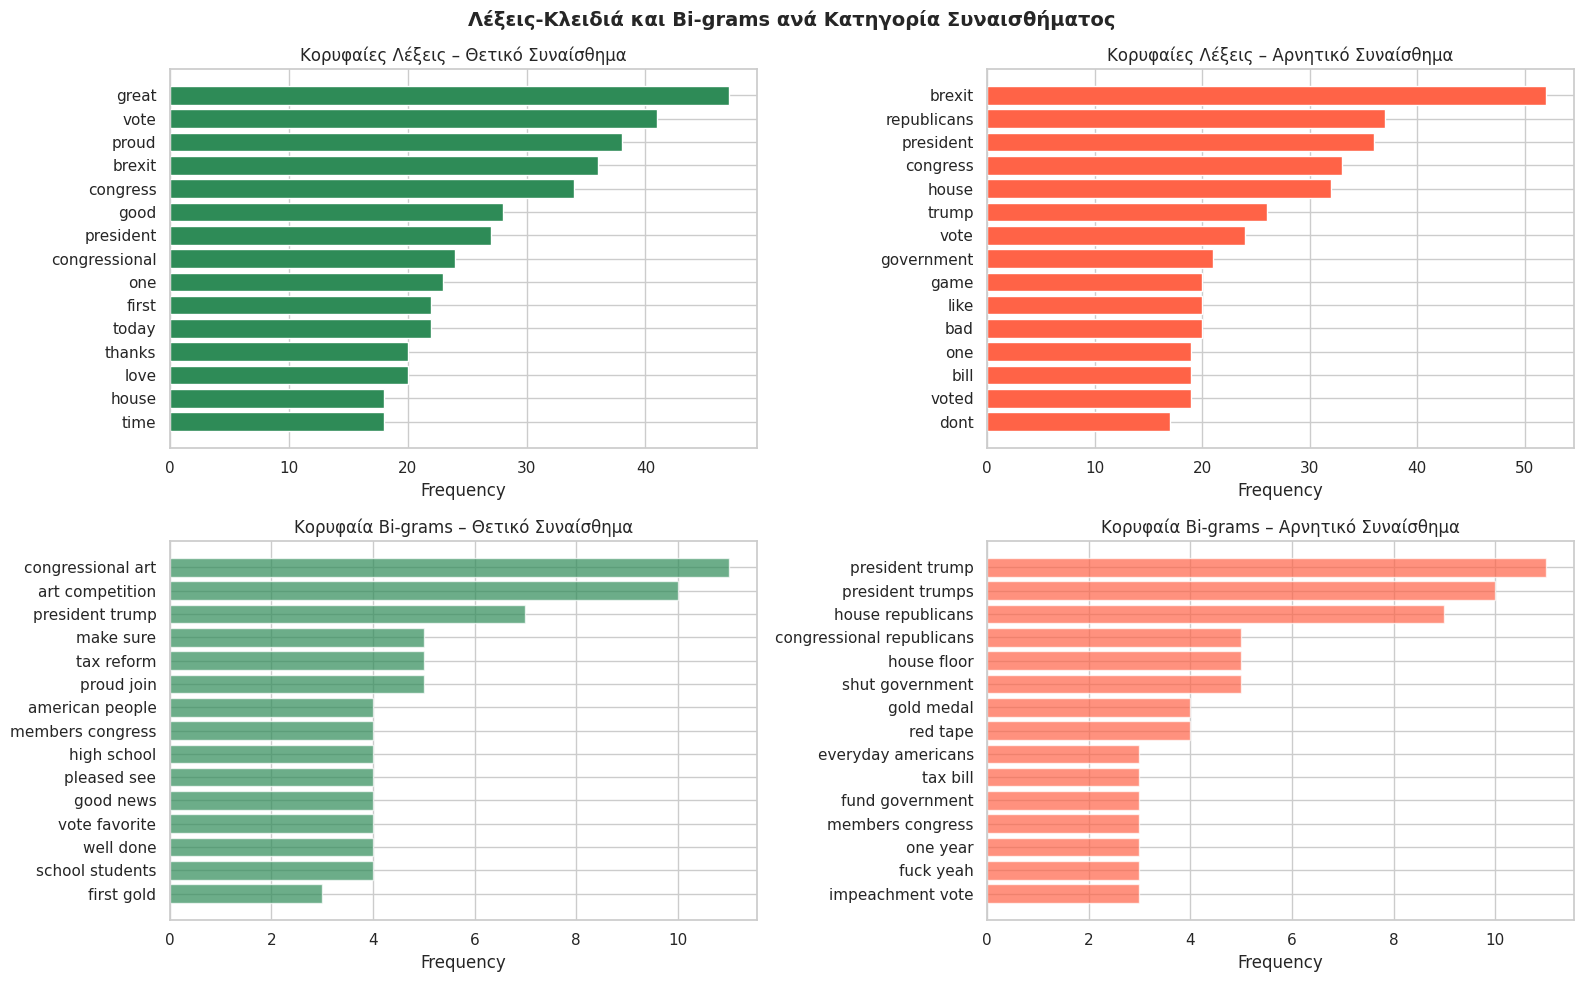


Κορυφαίες 5 λέξεις-κλειδιά ανά συναίσθημα:
  Positive: λέξεις=['great', 'vote', 'proud', 'brexit', 'congress']
            bi-grams=['congressional art', 'art competition', 'president trump']
  Negative: λέξεις=['brexit', 'republicans', 'president', 'congress', 'house']
            bi-grams=['president trump', 'president trumps', 'house republicans']

Αποκλειστικές θετικές λέξεις: ['love', 'good', 'thanks', 'congressional', 'first', 'today', 'great', 'time']
Αποκλειστικές αρνητικές λέξεις: ['bill', 'government', 'like', 'bad', 'game', 'voted', 'dont', 'republicans']


In [18]:
# Συχνότερες λέξεις-κλειδιά και bi-grams ανά κατηγορία συναισθήματος
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

keyword_data = {}
for i, sentiment in enumerate(['positive', 'negative']):
    sent_texts = df[df['sentiment'] == sentiment]['clean_text'].tolist()

    uni_vec = CountVectorizer(ngram_range=(1,1), max_features=200)
    uni_mat = uni_vec.fit_transform(sent_texts)
    uni_freq = np.asarray(uni_mat.sum(axis=0)).flatten()
    top_uni = pd.Series(uni_freq, index=uni_vec.get_feature_names_out()).sort_values(ascending=False).head(15)

    bi_vec = CountVectorizer(ngram_range=(2,2), max_features=200)
    bi_mat = bi_vec.fit_transform(sent_texts)
    bi_freq = np.asarray(bi_mat.sum(axis=0)).flatten()
    top_bi = pd.Series(bi_freq, index=bi_vec.get_feature_names_out()).sort_values(ascending=False).head(15)

    keyword_data[sentiment] = {'unigrams': top_uni, 'bigrams': top_bi}

    color = 'seagreen' if sentiment == 'positive' else 'tomato'
    axes[0][i].barh(top_uni.index[::-1], top_uni.values[::-1], color=color, edgecolor='white')
    axes[0][i].set_title(f'Κορυφαίες Λέξεις – {"Θετικό" if sentiment=="positive" else "Αρνητικό"} Συναίσθημα')
    axes[0][i].set_xlabel('Frequency')

    axes[1][i].barh(top_bi.index[::-1], top_bi.values[::-1], color=color, alpha=0.7, edgecolor='white')
    axes[1][i].set_title(f'Κορυφαία Bi-grams – {"Θετικό" if sentiment=="positive" else "Αρνητικό"} Συναίσθημα')
    axes[1][i].set_xlabel('Frequency')

plt.suptitle('Λέξεις-Κλειδιά και Bi-grams ανά Κατηγορία Συναισθήματος', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Dynamic commentary
print('\nΚορυφαίες 5 λέξεις-κλειδιά ανά συναίσθημα:')
for sent in ['positive', 'negative']:
    top5 = list(keyword_data[sent]['unigrams'].head(5).index)
    top5_bi = list(keyword_data[sent]['bigrams'].head(3).index)
    print(f'  {sent.capitalize()}: λέξεις={top5}')
    print(f'            bi-grams={top5_bi}')

# Shared vs exclusive keywords
pos_words = set(keyword_data['positive']['unigrams'].head(30).index)
neg_words = set(keyword_data['negative']['unigrams'].head(30).index)
exclusive_pos = pos_words - neg_words
exclusive_neg = neg_words - pos_words
print(f'\nΑποκλειστικές θετικές λέξεις: {list(exclusive_pos)[:8]}')
print(f'Αποκλειστικές αρνητικές λέξεις: {list(exclusive_neg)[:8]}')